# Test: Time-Decaying Resolve Rewards

Goal: verify that the agent stops exploiting the local optimum (MONITOR spam)
after introducing age-based reward decay (max_incident_age=72 steps = 72 hours).

Branch: `feature/train-single-house`

In [1]:
from setup import setup_modules
setup_modules()

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from building_maintenance_agents.envs import BuildingIncidentEnv
from building_maintenance_agents.envs.training import make_env, train_agent, evaluate_agent
from building_maintenance_agents.envs.reward import RewardConfig, CurrentReward

## 1. Sanity-check: decay factor behaviour

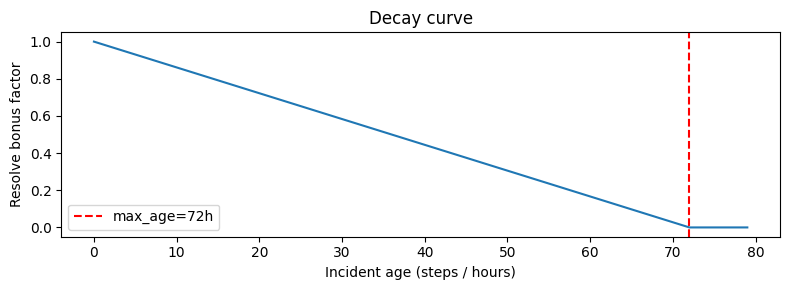

deploy_resolved_bonus: 20.0
  age=  0h  factor=1.00  bonus=20.0
  age= 12h  factor=0.83  bonus=16.7
  age= 24h  factor=0.67  bonus=13.3
  age= 48h  factor=0.33  bonus=6.7
  age= 72h  factor=0.00  bonus=0.0


In [2]:
cfg = RewardConfig()
ages = np.arange(0, 80, 1)
factors = [max(cfg.min_resolve_bonus_factor, 1 - a / cfg.max_incident_age) for a in ages]

plt.figure(figsize=(8, 3))
plt.plot(ages, factors)
plt.axvline(cfg.max_incident_age, color='red', linestyle='--', label=f'max_age={cfg.max_incident_age}h')
plt.xlabel('Incident age (steps / hours)')
plt.ylabel('Resolve bonus factor')
plt.title('Decay curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f'deploy_resolved_bonus: {cfg.deploy_resolved_bonus}')
for age in [0, 12, 24, 48, 72]:
    f = max(cfg.min_resolve_bonus_factor, 1 - age / cfg.max_incident_age)
    print(f'  age={age:3d}h  factor={f:.2f}  bonus={cfg.deploy_resolved_bonus * f:.1f}')

## 2. Environment check (house_type=15)

In [4]:
ENV_CONFIG = dict(
    house_type='16',
    max_steps=200,
    incident_probability=0.03,
    resource_budget=100.0,
    enable_spread=True,
)

env = BuildingIncidentEnv(**ENV_CONFIG)
obs, info = env.reset(seed=42)
print(f'Observation shape : {obs.shape}')
print(f'Action space      : {env.action_space}')
print(f'Nodes / Edges     : {info["num_nodes"]} / {info["num_edges"]}')

2026-05-12 18:27:07.155 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:27:07.156 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:27:07.182 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:27:07.183 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03


Observation shape : (18537,)
Action space      : Box([0.  0.  0.  0.5], [6.000e+00 1.371e+03 1.000e+00 2.000e+00], (4,), float32)
Nodes / Edges     : 513 / 1372


## 3. Action distribution baseline (random policy)

In [5]:
from building_maintenance_agents.envs.agent_action_type import AgentActionType

def run_episodes(env, policy_fn, n_episodes=10):
    """Returns per-episode rewards and action type counts."""
    all_rewards = []
    action_counts = defaultdict(int)
    resolve_ages = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=ep)
        ep_reward = 0.0
        done = False

        while not done:
            action = policy_fn(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)
            ep_reward += reward
            action_counts[info['action']] += 1
            done = terminated or truncated

        all_rewards.append(ep_reward)

    return all_rewards, dict(action_counts)


random_rewards, random_actions = run_episodes(
    env,
    policy_fn=lambda obs, e: e.action_space.sample(),
    n_episodes=20
)

print(f'Random policy — mean reward: {np.mean(random_rewards):.2f} ± {np.std(random_rewards):.2f}')
print('Action distribution:')
total = sum(random_actions.values())
for k, v in sorted(random_actions.items(), key=lambda x: -x[1]):
    print(f'  {k:20s} {v:5d}  ({100*v/total:.1f}%)')

2026-05-12 18:27:27.904 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:27:27.905 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:27:30.243 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:27:30.243 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:27:32.604 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:27:32.604 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:27:34.902 | INFO 

Random policy — mean reward: 139.02 ± 23.57
Action distribution:
  WITHDRAW_TEAM          700  (17.5%)
  INSPECT                681  (17.0%)
  REPAIR                 673  (16.8%)
  SHUT_OFF_WATER         660  (16.5%)
  MONITOR                653  (16.3%)
  DEPLOY_TEAM            633  (15.8%)


## 4. Train PPO with decay reward

In [6]:
model = train_agent(
    ENV_CONFIG,
    total_timesteps=200_000,
    algorithm='PPO',
    n_envs=4,
    save_path='./models/decay_reward/'
)

2026-05-12 18:28:42.196 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:28:42.196 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:28:42.196 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:28:42.197 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:28:42.197 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:28:42.197 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-0

Using cpu device
Logging to ./models/decay_reward//tensorboard/PPO_incident_control_1


2026-05-12 18:28:47.967 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:28:47.967 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:28:47.967 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:28:47.967 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:28:47.968 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:28:47.968 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-0

-----------------------------
| time/              |      |
|    fps             | 291  |
|    iterations      | 1    |
|    time_elapsed    | 28   |
|    total_timesteps | 8192 |
-----------------------------


2026-05-12 18:29:15.891 | INFO     | building_maintenance_agents.house_graph.states.incident_state:update_incident:25 - Update incident: gvs_riser_failure: severity 0.57
2026-05-12 18:29:15.891 | INFO     | building_maintenance_agents.house_graph.states.incident_state:update_incident:25 - Update incident: gvs_riser_failure: severity 0.19
2026-05-12 18:29:15.891 | INFO     | building_maintenance_agents.house_graph.states.incident_state:update_incident:25 - Update incident: gvs_riser_failure: severity 0.19
2026-05-12 18:29:15.892 | INFO     | building_maintenance_agents.house_graph.states.incident_state:update_incident:25 - Update incident: gvs_riser_failure: severity 0.19
2026-05-12 18:29:15.892 | INFO     | building_maintenance_agents.house_graph.states.incident_state:update_incident:25 - Update incident: gvs_riser_failure: severity 0.19
2026-05-12 18:29:15.892 | INFO     | building_maintenance_agents.house_graph.states.incident_state:update_incident:25 - Update incident: gvs_riser_fai

...

2026-05-12 18:43:32.750 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:43:32.750 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:43:32.750 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:43:32.751 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:43:32.751 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:43:32.751 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-0

Eval num_timesteps=200000, episode_reward=114.58 +/- 10.83
Episode length: 200.00 +/- 0.00
------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 200          |
|    mean_reward          | 115          |
| time/                   |              |
|    total_timesteps      | 200000       |
| train/                  |              |
|    approx_kl            | 0.0055164252 |
|    clip_fraction        | 0.059        |
|    clip_range           | 0.2          |
|    entropy_loss         | -6.51        |
|    explained_variance   | 1.19e-07     |
|    learning_rate        | 0.0003       |
|    loss                 | 2.54         |
|    n_updates            | 240          |
|    policy_gradient_loss | -0.00208     |
|    std                  | 1.25         |
|    value_loss           | 4.5          |
------------------------------------------


2026-05-12 18:43:57.930 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:43:57.930 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:43:57.930 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:43:57.931 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:43:57.931 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:43:57.931 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-0

-------------------------------
| time/              |        |
|    fps             | 221    |
|    iterations      | 25     |
|    time_elapsed    | 923    |
|    total_timesteps | 204800 |
-------------------------------


2026-05-12 18:44:11.453 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:11.453 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:11.453 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:11.453 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:11.454 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:44:11.454 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-0

## 5. Evaluate: reward & action distribution

In [7]:
episode_rewards, episode_lengths = evaluate_agent(
    './models/decay_reward/PPO_incident_model.zip',
    n_episodes=20
)

2026-05-12 18:44:35.312 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:35.312 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:44:35.336 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:35.337 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03



Step: 1
Resources: 100.0/100.0
Active incidents: 0
Total reward: 0.60

Statistics: total incidents=0, max active=0

Step: 2
Resources: 100.0/100.0
Active incidents: 0
Total reward: 1.20

Statistics: total incidents=0, max active=0

Step: 3
Resources: 100.0/100.0
Active incidents: 0
Total reward: 1.80

Statistics: total incidents=0, max active=0

Step: 4
Resources: 100.0/100.0
Active incidents: 0
Total reward: 2.40

Statistics: total incidents=0, max active=0

Step: 5
Resources: 100.0/100.0
Active incidents: 0
Total reward: 3.00

Statistics: total incidents=0, max active=0

Step: 6
Resources: 100.0/100.0
Active incidents: 0
Total reward: 3.60

Statistics: total incidents=0, max active=0

Step: 7
Resources: 100.0/100.0
Active incidents: 0
Total reward: 4.20

Statistics: total incidents=0, max active=0

Step: 8
Resources: 100.0/100.0
Active incidents: 0
Total reward: 4.80

Statistics: total incidents=0, max active=0

Step: 9
Resources: 100.0/100.0
Active incidents: 0
Total reward: 5.40



2026-05-12 18:44:36.540 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:36.541 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03



Step: 90
Resources: 100.0/100.0
Active incidents: 0
Total reward: 54.00

Statistics: total incidents=0, max active=0

Step: 91
Resources: 100.0/100.0
Active incidents: 0
Total reward: 54.60

Statistics: total incidents=0, max active=0

Step: 92
Resources: 100.0/100.0
Active incidents: 0
Total reward: 55.20

Statistics: total incidents=0, max active=0

Step: 93
Resources: 100.0/100.0
Active incidents: 0
Total reward: 55.80

Statistics: total incidents=0, max active=0

Step: 94
Resources: 100.0/100.0
Active incidents: 0
Total reward: 56.40

Statistics: total incidents=0, max active=0

Step: 95
Resources: 100.0/100.0
Active incidents: 0
Total reward: 57.00

Statistics: total incidents=0, max active=0

Step: 96
Resources: 100.0/100.0
Active incidents: 0
Total reward: 57.60

Statistics: total incidents=0, max active=0

Step: 97
Resources: 100.0/100.0
Active incidents: 0
Total reward: 58.20

Statistics: total incidents=0, max active=0

Step: 98
Resources: 100.0/100.0
Active incidents: 0
Tot

2026-05-12 18:44:37.729 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:37.729 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03


...


Step: 85
Resources: 100.0/100.0
Active incidents: 0
Total reward: 51.00

Statistics: total incidents=0, max active=0

Step: 86
Resources: 100.0/100.0
Active incidents: 0
Total reward: 51.60

Statistics: total incidents=0, max active=0

Step: 87
Resources: 100.0/100.0
Active incidents: 0
Total reward: 52.20

Statistics: total incidents=0, max active=0

Step: 88
Resources: 100.0/100.0
Active incidents: 0
Total reward: 52.80

Statistics: total incidents=0, max active=0

Step: 89
Resources: 100.0/100.0
Active incidents: 0
Total reward: 53.40

Statistics: total incidents=0, max active=0

Step: 90
Resources: 100.0/100.0
Active incidents: 0
Total reward: 54.00

Statistics: total incidents=0, max active=0

Step: 91
Resources: 100.0/100.0
Active incidents: 0
Total reward: 54.60

Statistics: total incidents=0, max active=0

Step: 92
Resources: 100.0/100.0
Active incidents: 0
Total reward: 55.20

Statistics: total incidents=0, max active=0

Step: 93
Resources: 100.0/100.0
Active incidents: 0
Tot

2026-05-12 18:44:56.941 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:56.942 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03



Step: 89
Resources: 100.0/100.0
Active incidents: 0
Total reward: 53.40

Statistics: total incidents=0, max active=0

Step: 90
Resources: 100.0/100.0
Active incidents: 0
Total reward: 54.00

Statistics: total incidents=0, max active=0

Step: 91
Resources: 100.0/100.0
Active incidents: 0
Total reward: 54.60

Statistics: total incidents=0, max active=0

Step: 92
Resources: 100.0/100.0
Active incidents: 0
Total reward: 55.20

Statistics: total incidents=0, max active=0

Step: 93
Resources: 100.0/100.0
Active incidents: 0
Total reward: 55.80

Statistics: total incidents=0, max active=0

Step: 94
Resources: 100.0/100.0
Active incidents: 0
Total reward: 56.40

Statistics: total incidents=0, max active=0

Step: 95
Resources: 100.0/100.0
Active incidents: 0
Total reward: 57.00

Statistics: total incidents=0, max active=0

Step: 96
Resources: 100.0/100.0
Active incidents: 0
Total reward: 57.60

Statistics: total incidents=0, max active=0

Step: 97
Resources: 100.0/100.0
Active incidents: 0
Tot

2026-05-12 18:44:58.147 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:44:58.147 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03



Step: 93
Resources: 100.0/100.0
Active incidents: 0
Total reward: 55.80

Statistics: total incidents=0, max active=0

Step: 94
Resources: 100.0/100.0
Active incidents: 0
Total reward: 56.40

Statistics: total incidents=0, max active=0

Step: 95
Resources: 100.0/100.0
Active incidents: 0
Total reward: 57.00

Statistics: total incidents=0, max active=0

Step: 96
Resources: 100.0/100.0
Active incidents: 0
Total reward: 57.60

Statistics: total incidents=0, max active=0

Step: 97
Resources: 100.0/100.0
Active incidents: 0
Total reward: 58.20

Statistics: total incidents=0, max active=0

Step: 98
Resources: 100.0/100.0
Active incidents: 0
Total reward: 58.80

Statistics: total incidents=0, max active=0

Step: 99
Resources: 100.0/100.0
Active incidents: 0
Total reward: 59.40

Statistics: total incidents=0, max active=0

Step: 100
Resources: 100.0/100.0
Active incidents: 0
Total reward: 60.00

Statistics: total incidents=0, max active=0
Episode 19: reward=60.00, steps=100
  Incidents handled

2026-05-12 18:45:38.140 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:45:38.141 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:45:40.478 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:45:40.478 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:45:42.827 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:58 - IncidentSimulator initialized with 513 nodes, 1372 edges
2026-05-12 18:45:42.827 | INFO     | building_maintenance_agents.incident_simulator.incident_simulator:__init__:59 - Base incident probability: 0.03
2026-05-12 18:45:45.164 | INFO 

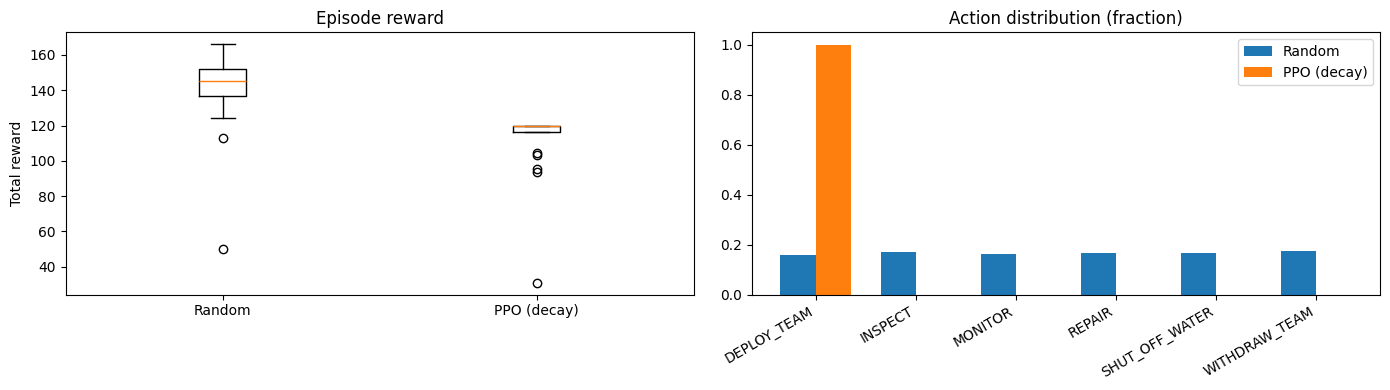

Random : 139.02 ± 23.57
PPO    : 111.42 ± 20.31


In [8]:
from stable_baselines3 import PPO

model_eval = PPO.load('./models/decay_reward/PPO_incident_model.zip')

ppo_rewards, ppo_actions = run_episodes(
    env,
    policy_fn=lambda obs, e: model_eval.predict(obs, deterministic=True)[0],
    n_episodes=20
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# reward comparison
axes[0].boxplot([random_rewards, ppo_rewards], labels=['Random', 'PPO (decay)'])
axes[0].set_title('Episode reward')
axes[0].set_ylabel('Total reward')

# action distribution comparison
all_actions = sorted(set(list(random_actions) + list(ppo_actions)))
x = np.arange(len(all_actions))
w = 0.35
r_vals = [random_actions.get(a, 0) for a in all_actions]
p_vals = [ppo_actions.get(a, 0) for a in all_actions]
r_total = max(sum(r_vals), 1)
p_total = max(sum(p_vals), 1)
axes[1].bar(x - w/2, [v/r_total for v in r_vals], w, label='Random')
axes[1].bar(x + w/2, [v/p_total for v in p_vals], w, label='PPO (decay)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_actions, rotation=30, ha='right')
axes[1].set_title('Action distribution (fraction)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Random : {np.mean(random_rewards):.2f} ± {np.std(random_rewards):.2f}')
print(f'PPO    : {np.mean(ppo_rewards):.2f} ± {np.std(ppo_rewards):.2f}')

## 6. Check: is MONITOR being spammed?

If the agent learned to deal with incidents (not just MONITOR),
`MONITOR` fraction should be noticeably lower than in the random policy,
and `DEPLOY_TEAM` / `REPAIR` fractions should be higher when incidents are active.

In [9]:
print('PPO action distribution:')
total = max(sum(ppo_actions.values()), 1)
for k, v in sorted(ppo_actions.items(), key=lambda x: -x[1]):
    print(f'  {k:20s} {v:5d}  ({100*v/total:.1f}%)')

PPO action distribution:
  DEPLOY_TEAM           4000  (100.0%)
